In [ ]:
import pandas as pd

all_data = pd.read_excel('../../../data/raw/experts_merged.xlsx', na_values=['not given'])
all_data = all_data[all_data['dataset'].isin(['expert1', 'expert2', 'expert3'])]
all_data = all_data.dropna(subset=['smiles', 'SMILES to be used', 'capacity_max'])
all_data = all_data.drop_duplicates(subset=['SMILES to be used', 'capacity_max'])
all_data = all_data[['SMILES to be used', 'capacity_max']]
all_data = all_data.rename(columns={'SMILES to be used': 'smiles', 'capacity_max': 'capacity_max'})
all_data
all_data.to_csv('../../../data/raw/new_smiles_experts123.csv', index=False)

In [6]:
new_dit = '../../../data/custom_expert_substructures/'
import os
import pandas as pd
df1 = pd.read_csv('../../../data/processed_selected_custom_features/data_substrates_june2025_no_outliers.csv')
df2 = pd.read_csv('../../../data/processed_expert_substructures/data_substrates_june2025_no_outliers.csv')
df = pd.merge(df1, df2, how='left', on='smiles')
df['capacity_max'] = df['capacity_max_x']
df.drop(columns=['capacity_max_x', 'capacity_max_y'], inplace=True)
os.makedirs(new_dit, exist_ok=True)
df.to_csv(os.path.join(new_dit, 'data_substrates_june2025_no_outliers.csv'), index=False)
df

,smiles,flatness,radius,diameter,balaban_j_index,%C,%N,%O,MolLogP,num_atoms,...,num_h_acceptors,num_h_donors,tpsa,mol_wt,expert_feature_2,expert_feature_10,expert_feature_11,expert_feature_14,expert_feature_15,capacity_max
0,N#Cc1ccc(C#N)cc1,0.051385,4,7,3.075217,80.000000,20.000000,0.000000,1.42996,10,...,2,0,47.58,128.037448,0,0,0,0,0,628.0
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,1.847534,8,16,1.652035,90.476190,9.523810,0.000000,9.74536,42,...,4,0,57.44,544.262697,0,0,0,0,0,255.0
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(C...,1.468051,8,16,1.457648,81.818182,13.636364,0.000000,9.33480,44,...,6,0,83.22,602.134737,0,0,0,0,0,269.0
3,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,0.744660,10,18,1.287446,68.750000,18.750000,0.000000,10.16400,48,...,9,0,116.01,746.958158,0,0,0,0,0,228.0
4,O=C1c2ccc(Nc3nc(Cl)nc(Cl)n3)cc2C(=O)c2ccc(Nc3n...,0.728578,9,17,1.457455,58.823529,23.529412,5.882353,4.93280,34,...,10,2,135.54,531.952432,1,0,0,0,0,468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,CCCCCCCCN1C(=O)C2=C(c3ccc(/C=N/c4ccc(-c5cc(-c6...,1.980776,14,28,1.081588,84.848485,7.575758,4.545455,14.06590,66,...,8,4,122.09,913.405933,1,0,1,0,0,50.0
99,Nc1ccc(-c2ccc3c(c2)C2(c4cc(-c5ccc(N)cc5)ccc4-3...,2.786990,12,23,1.133945,91.935484,6.451613,1.612903,13.00780,62,...,5,6,107.49,796.320212,1,0,0,0,0,251.0
100,Nc1ccc(-c2ccc(/N=C/c3ccc([Sb](c4ccc(C=O)cc4)c4...,1.681720,11,21,1.397576,82.500000,5.000000,10.000000,4.23880,40,...,6,4,112.98,634.085248,0,0,0,0,0,768.0
101,Nc1ccc(-c2ccc(/N=C/c3ccc([Sb](c4ccc(C=O)cc4)c4...,1.527354,11,21,1.372479,86.842105,5.263158,5.263158,4.82760,38,...,4,2,72.52,602.095419,0,0,0,0,0,393.0


In [6]:
import pandas as pd
import numpy as np
from scipy import stats
df = pd.read_csv('../../../../old/data_substrates_june2025.csv')
df['z_score'] = np.abs(stats.zscore(df['capacity_max']))

# Identify outliers based on a Z-score threshold (e.g., 3)
outliers = df[df['z_score'] > 3]
df = df[df['z_score'] <= 3]
df = df.drop(columns=['z_score'])
df.to_csv('../../../data/raw/data_substrates_june2025_no_outliers.csv', index=False)

In [8]:
from modules.core.features.preprocessing import canon_smiles
import os
import pandas as pd
import numpy as np

data_path = '../../../../data/raw/old'
data = 'data_experts1_corrected.csv'
data_type = 'expert'
fingerprint = 'estate'
kwargs = {'variant': 'sum'}
df = pd.read_csv(os.path.join(data_path, data))
df = df[['smiles_old', 'temperatura', 'pojemnosc_3_H2SO4_GCD', 'pojemnosc_3_NaOH_GCD', 'pojemnosc_3_H2SO4_CV', 'pojemnosc_3_NaOH_CV']]
df = df.rename(columns={'pojemnosc_3_H2SO4_GCD': 'capacity_H2SO4_GCD', 'pojemnosc_3_NaOH_GCD': 'capacity_NaOH_GCD', 'pojemnosc_3_H2SO4_CV': 'capacity_H2SO4_CV', 'pojemnosc_3_NaOH_CV': 'capacity_NaOH_CV', 'temperatura': 'temperature'})
df['capacity_H2SO4'] = np.nanmean(df[['capacity_H2SO4_GCD', 'capacity_H2SO4_CV']], axis=1)
df['capacity_NaOH'] = np.nanmean(df[['capacity_NaOH_GCD', 'capacity_NaOH_CV']], axis=1)
df['capacity_max'] = df[['capacity_H2SO4', 'capacity_NaOH']].max(axis=1)
df.drop(columns=['capacity_H2SO4_GCD', 'capacity_H2SO4_CV', 'capacity_NaOH_GCD', 'capacity_NaOH_CV'], inplace=True)
#df["smiles"] = df["smiles"].apply(canon_smiles)
df
# #df = fingerprints_dataset(df, "smiles", "capacity_max", fingerprint, kwargs=kwargs)
# df = pd.melt(
#     df,
#     id_vars=['smiles', 'temperature', 'capacity_max'],  # Columns to keep
#     value_vars=['capacity_H2SO4', 'capacity_NaOH'],  # Columns to unpivot
#     var_name='electrolyte',  # Name of the new column for electrolytes
#     value_name='capacity'  # Name of the new column for capacities
# )
df
#
# # Clean up the 'electrolyte' column to remove the 'capacity_' prefix
# df['electrolyte'] = df['electrolyte'].str.replace('capacity_', '', regex=False)
# df = df.dropna()
# df

/tmp/ipykernel_21602/1246418901.py:14: RuntimeWarning: Mean of empty slice
  df['capacity_H2SO4'] = np.nanmean(df[['capacity_H2SO4_GCD', 'capacity_H2SO4_CV']], axis=1)
/tmp/ipykernel_21602/1246418901.py:15: RuntimeWarning: Mean of empty slice
  df['capacity_NaOH'] = np.nanmean(df[['capacity_NaOH_GCD', 'capacity_NaOH_CV']], axis=1)


,smiles_old,temperature,capacity_H2SO4,capacity_NaOH,capacity_max
0,CC(C)C(C=C1)=CC=C1N2C(C=C(C3=CC=C(C#N)C=C3)N4C...,500.0,151.5,NaN,151.5
1,CC(C)C(C=C1)=CC=C1N2C(C=C(C3=CC=C(C#N)C=C3)N4C...,600.0,174.0,NaN,174.0
2,CC(C)C(C=C1)=CC=C1N2C(C=C(C3=CC=C(C#N)C=C3)N4C...,700.0,219.5,NaN,219.5
3,N#CC1=CC=C(C#N)C=C1,700.0,202.0,NaN,202.0
4,N#C/C(C#N)=C(C=C/1)/C=CC1=C(C#N)/C#N,700.0,298.5,NaN,298.5
...,...,...,...,...,...
61,NC(N=C1)=CC=C1C2=NC(C3=CC=C(N=CC4=C(O)C(C=O)=C...,120.0,400.0,NaN,400.0
62,N#CC1=C2C(C=CC=C2)=C(C#N)C3=CC=CC=C31,400.0,NaN,435.0,435.0
63,N#CC1=C2C(C=CC=C2)=C(C#N)C3=CC=CC=C31,500.0,NaN,589.0,589.0
64,C#CC(C=C1)=CC=C1C#N,800.0,628.0,NaN,628.0


In [ ]:
import pandas as pd

df = pd.read_csv('expert1_old.csv')
df.loc[:, 'nan_flat'] = df['flatness'].isna()
df = df.loc[:, ['smiles', 'nan_flat']]
df

In [ ]:
import pandas as pd
data = pd.read_csv('../../../data/raw/data_experts1.csv')
data['pojemnosc_nan'] = (data['pojemnosc_3_H2SO4_GCD'].isna()) & (data['pojemnosc_3_NaOH_GCD'].isna()) & (data['pojemnosc_3_H2SO4_CV'].isna()) & (data['pojemnosc_3_NaOH_CV'].isna())
data = data[~data['pojemnosc_nan']]
data.drop(columns=['pojemnosc_nan'], inplace=True)
data = data[['zwiazek', 'temperatura', 'pojemnosc_3_H2SO4_GCD', 'pojemnosc_3_NaOH_GCD', 'pojemnosc_3_H2SO4_CV', 'pojemnosc_3_NaOH_CV', 'smiles']]

grouped = data.groupby('zwiazek')

for name, group in grouped:
    if len(group) > 0:
        print(f"Group: {name}")
        display(group[['temperatura', 'pojemnosc_3_H2SO4_GCD', 'pojemnosc_3_NaOH_GCD', 'pojemnosc_3_H2SO4_CV', 'pojemnosc_3_NaOH_CV']])
        #print(group)
        print("\n")
data.head()

In [ ]:
from rdkit import Chem

df.loc[:, 'num_atoms'] = df['smiles'].apply(lambda x: Chem.MolFromSmiles(x).GetNumAtoms())
df.loc[:, 'num_bonds'] = df['smiles'].apply(lambda x: Chem.MolFromSmiles(x).GetNumBonds())
df.loc[:, 'size'] = df['num_atoms'] + df['num_bonds']
df

In [ ]:
import time
from modules.core.features.flatness import get_flatness_smiles
import seaborn as sns
from rdkit.Chem import Mol, rdDepictor, rdDistGeom
random_seed = 321
times = []
force_tols = [0.001, 0.005, 0.01, 0.05, 0.1, 1]
for force_tol in force_tols:
    for s in df[df['nan_flat']]['smiles'].tolist()[:1]:
        mol = Chem.MolFromSmiles(s)
        print(s)
        print(mol.GetNumAtoms(), mol.GetNumBonds())

        mol = Chem.AddHs(mol)

        #rdDepictor.Compute2DCoords(mol)
        time_start = time.time()
        a = rdDistGeom.EmbedMolecule(mol, randomSeed=random_seed, maxAttempts=500, useRandomCoords=True, forceTol=force_tol)
        times.append(time.time() - time_start)
        # print(a)
        # print(mol.GetNumConformers())
        #a = rdDistGeom.EmbedMultipleConfs(mol, 8, randomSeed=random_seed, useRandomCoords=True, numThreads=8)
        #print(mol.GetNumConformers())
        print('-----------------------------------------------------')
df_time = pd.DataFrame({'force_tol': force_tols, 'time': times})
display(df_time)
sns.lineplot(x=force_tols, y=times)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.boxplot(x='nan_flat', y='num_atoms', data=df)
plt.title('Box Plot of num_atoms by nan_flat')
plt.xlabel('nan_flat')
plt.ylabel('num_atoms')

# Create a box plot for num_bonds
plt.subplot(2, 2, 2)
sns.boxplot(x='nan_flat', y='num_bonds', data=df)
plt.title('Box Plot of num_bonds by nan_flat')
plt.xlabel('nan_flat')
plt.ylabel('num_bonds')

plt.subplot(2, 2, 3)
sns.boxplot(x='nan_flat', y='size', data=df)
plt.title('Box Plot of size by nan_flat')
plt.xlabel('nan_flat')
plt.ylabel('size')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.kdeplot(df, x='num_atoms', hue='nan_flat', fill=True, cut=True, )

# Create a box plot for num_bonds
plt.subplot(2, 2, 2)
sns.kdeplot(df, x='num_bonds', hue='nan_flat', fill=True, cut=True)

plt.subplot(2, 2, 3)
sns.kdeplot(df, x='size', hue='nan_flat', fill=True, cut=True)

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.histplot(df, x='num_atoms', hue='nan_flat', fill=True, bins=len(df))

# Create a box plot for num_bonds
plt.subplot(2, 2, 2)
sns.histplot(df, x='num_bonds', hue='nan_flat', fill=True, bins=len(df))

plt.subplot(2, 2, 3)
sns.histplot(df, x='size', hue='nan_flat', fill=True, bins=len(df))

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from modules.predictor.data.utils import data_preprocessing

# df_experts1 = pd.read_csv('../../../data/raw/data_experts1.csv')
df_experts1 = data_preprocessing('../../../data/raw/data_experts1.csv', 'expert')
df_experts1

In [ ]:
wrong_smiles = pd.read_csv('wrong_smiles.csv')
wrong_smiles = wrong_smiles.astype(str)
wrong_smiles['pore_size_info'] = 'estimated: ' + wrong_smiles['estimated'] + ', true: ' + wrong_smiles['true']
wrong_smiles

In [ ]:
wrong_smiles = wrong_smiles[~wrong_smiles['pore_size_info'].str.contains('min')]
wrong_smiles

In [ ]:
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools
PandasTools.AddMoleculeColumnToFrame(wrong_smiles, smilesCol='smiles')

#mols = [Chem.MolFromSmiles(smi) for smi in smiles]
#display(Draw.MolsToGridImage(mols, molsPerRow=4))
display(PandasTools.FrameToGridImage(wrong_smiles, legendsCol="pore_size_info", molsPerRow=3, subImgSize=(400, 400)))
print('--------------------------------------------')

In [ ]:
from pymatgen.io.ase import AseAtomsAdaptor
from ase.visualize import view
from pymatgen.vis.structure_chemview import quick_view
from modules.core.features.symmetries import translate_point_group_to_symmetry_description
from modules.core.features.utils import get_pymatgen_molecule_from_smiles
from pymatgen.symmetry.analyzer import PointGroupAnalyzer
import pandas as pd
import numpy as np

from pymatgen.vis.structure_vtk import StructureVis

from rdkit import Chem
from rdkit.Chem import AllChem, Mol, MolToXYZFile, rdDepictor, rdDistGeom
import matplotlib.pyplot as plt

from modules.core.features.preprocessing import canon_smiles

df = pd.read_csv('../../../data/raw/data_experts1_corrected.csv')
df = df[['smiles_old', 'wielkosc_pora teoretyczna']].groupby('smiles_old').aggregate('mean').reset_index()
#pore_sizes = df['wielkosc_pora teoretyczna'].tolist()
df_smiles = pd.read_excel('../../../data/raw/data_battery_materials.xlsx', na_values=['not given'])
df_smiles = df_smiles[df_smiles['dataset'] == 'expert1']
df_smiles = df_smiles[['smiles', 'SMILES to be used']]
df_smiles = df_smiles.rename(columns={'SMILES to be used': 'smiles_new', 'smiles': 'smiles_old'})
df = df.merge(df_smiles, on='smiles_old', how='inner')
df['canon_smiles'] = [canon_smiles(s) for s in df['smiles_new'].tolist()]
df = df[['canon_smiles', 'wielkosc_pora teoretyczna']]
pore_sizes = df['wielkosc_pora teoretyczna'].tolist()
df

In [ ]:
import warnings
warnings.filterwarnings('ignore')

smiles = df['canon_smiles'].tolist()

# smiles = df.drop_duplicates(subset=['smiles'])['smiles'].tolist()
# smiles = [canon_smiles(s) for s in smiles]
#
for s, p in zip(smiles, pore_sizes):
    TRANSLATION_TABLE_PATH = "../../../../data/symmetries/symmetry_translation.csv"

    molecule = get_pymatgen_molecule_from_smiles(s, save_file=True)
    pga = PointGroupAnalyzer(molecule)
    symmetry_operations = pga.get_symmetry_operations()
    rotational_symmetry = pga.get_rotational_symmetry_number()
    point_group = pga.get_pointgroup()
    equivalent_atoms = pga.get_equivalent_atoms()

    # print(f"Symmetry operations: {symmetry_operations}")
    # print(f"Rotational symmetry number: {rotational_symmetry}")
    print(f"Point group: {point_group}")
    #print(pga.inversion_op)
    #print(f"Equivalent atoms: {equivalent_atoms}")

    symmetry_description = translate_point_group_to_symmetry_description(str(point_group), TRANSLATION_TABLE_PATH)
    print(f"Symmetry description: {symmetry_description}")
    #structure = molecule.get_boxed_structure(23, 23, 23)

    #view(AseAtomsAdaptor().get_atoms(structure))
    # coordinates = []
    # species = []
    #
    # for s in structure:
    #         coordinates.append(s.coords) #cartesian coordinates
    #         species.append(s.specie)
    #
    # print(coordinates)
    # print(species)
    molecule = Chem.MolFromSmiles(s, sanitize=True)
    molecule = Chem.AddHs(molecule)
    #rdDepictor.Compute2DCoords(molecule, sampleSeed=42)
    rdDistGeom.EmbedMolecule(molecule, randomSeed=42, maxAttempts=500, useRandomCoords=True)

    nitrogen_indices = [
            bond.GetEndAtomIdx() if bond.GetBeginAtom().GetSymbol() == "C" and bond.GetEndAtom().GetSymbol() == "N" else bond.GetBeginAtomIdx()
            for bond in molecule.GetBonds()
            if bond.GetBondType() == Chem.BondType.TRIPLE and {"C", "N"} == {bond.GetBeginAtom().GetSymbol(), bond.GetEndAtom().GetSymbol()}
        ]
    oxygen_indices = [
            bond.GetEndAtomIdx() if bond.GetBeginAtom().GetSymbol() == "C" and bond.GetEndAtom().GetSymbol() == "O" else bond.GetBeginAtomIdx()
            for bond in molecule.GetBonds()
            if bond.GetBondType() == Chem.BondType.DOUBLE and {"C", "O"} == {bond.GetBeginAtom().GetSymbol(), bond.GetEndAtom().GetSymbol()}
        ]
    # if len(nitrogen_indices) == 0:
    #     nitrogen_indices = [atom.GetIdx() for atom in molecule.GetAtoms() if atom.GetSymbol() != 'H']
    #     # nitrogen_indices = list(range(0, molecule.GetNumAtoms()))
    #     # nitrogen_indices = [
    #     #     bond.GetEndAtomIdx() if bond.GetBeginAtom().GetSymbol() != "H" and bond.GetEndAtom().GetSymbol() != "!" else bond.GetBeginAtomIdx()
    #     #     for bond in molecule.GetBonds()
    #     #     if bond.GetBondType() == Chem.BondType.TRIPLE and {"C", "N"} == {bond.GetBeginAtom().GetSymbol(), bond.GetEndAtom().GetSymbol()}
    #     # ]

    conf = molecule.GetConformer(0)
    coords = conf.GetPositions()

    nitrogen_distances = []
    nitrogen_atom_positions = []
    oxygen_distances = []
    oxygen_atom_positions = []
    max_distance = 0
    atom_pos_best = None

    for j in nitrogen_indices: #range(0, molecule.GetNumAtoms()):
        pos_j = np.array(conf.GetAtomPosition(j))

        # Calculate the distance between the two points
        distance = np.linalg.norm(np.array([0, 0, 0]) - pos_j)
        distance = distance * 6 / np.pi / 10
        nitrogen_distances.append(distance)
        nitrogen_atom_positions.append(pos_j)
        # if distance > max_distance:
        #     max_distance = distance
        #     atom_pos = pos_j
    for j in oxygen_indices: #range(0, molecule.GetNumAtoms()):
        pos_j = np.array(conf.GetAtomPosition(j))

        # Calculate the distance between the two points
        distance = np.linalg.norm(np.array([0, 0, 0]) - pos_j)
        distance = distance * 6 / np.pi / 10
        oxygen_distances.append(distance)
        oxygen_atom_positions.append(pos_j)


    indices = [atom.GetIdx() for atom in molecule.GetAtoms() if atom.GetSymbol() != 'H']
    for j in indices: #range(0, molecule.GetNumAtoms()):
        pos_j = np.array(conf.GetAtomPosition(j))

        # Calculate the distance between the two points
        distance = np.linalg.norm(np.array([0, 0, 0]) - pos_j)
        distance = distance * 6 / np.pi / 10
        if distance > max_distance:
            max_distance = distance
            atom_pos_best = pos_j

    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2])
    ax.scatter(0, 0, 0, c='red')
    for atom_pos in nitrogen_atom_positions:
        ax.scatter(atom_pos[0], atom_pos[1], atom_pos[2], c='green')
    for atom_pos in oxygen_atom_positions:
        ax.scatter(atom_pos[0], atom_pos[1], atom_pos[2], c='orange')
    if atom_pos_best is not None:
        ax.scatter(atom_pos_best[0], atom_pos_best[1], atom_pos_best[2], c='yellow')
    plt.show()
    display(Chem.Draw.MolsToImage([Chem.MolFromSmiles(s, sanitize=True)]))

    # perimeter = max_distance * 6
    # pore_diameter = perimeter / np.pi
    # pore_diameter = (max_distance * (3 ** 0.5) + max_distance * 2) / 2#perimeter / np.pi

    # pore_diameter_nm = pore_diameter / 10  # Convert to nanometers
    print(f'Smiles: {s}')
    print(f'Nitrogen pore sizes: {nitrogen_distances}, mean pore size: {np.mean(nitrogen_distances)}')
    print(f'Oxygen pore sizes: {oxygen_distances}, mean pore size: {np.mean(oxygen_distances)}')
    print(f'Overall mean: {np.mean(oxygen_distances + nitrogen_distances)}, pore size true: {p}')
    print(f'Pore size estimated: {max_distance}, pore size true: {p}')

    print('--------------------------------------------------------')

In [4]:
import pandas as pd
import os
maccs_path = '../../../../old/old/fingerprints_maccs/'
data_paths = ['data_experts1', 'data_zhu', 'data_saad', 'data_experts2', 'data_experts3']
dfs = []
for d in data_paths:
    df = pd.read_csv(os.path.join(maccs_path, f'{d}.csv'))
    df.columns = df.columns.str.replace(r"[\[\]>]", "", regex=True)
    df = df.sort_values(by="smiles").reset_index(drop=True)
    dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True).sort_values(by="smiles").reset_index(drop=True)
#df_all = df_all.loc[:, ~df_all.eq(df_all.iloc[0]).all()]
df_all.to_csv('maccs_merged_old_data.csv', index=False)


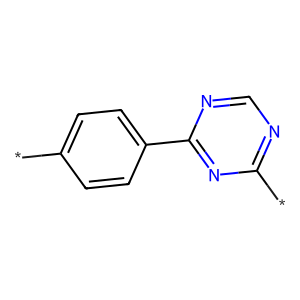

In [3]:
smiles = '*C1=CC=C(C2=NC(*)=NC=N2)C=C1'
from rdkit import Chem
mol = Chem.MolFromSmiles(smiles)
print(mol)
Chem.Draw.MolToImage(mol)

In [13]:
from modules.predictor.data.fingerprints import Fingerprints

maccs = Fingerprints().apply('maccs', [smiles], count=False)
maccs[0]

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0]], dtype=uint8)

In [5]:
import pandas as pd
import os
# dir_path = '../../../data/'
# data_paths = ['data_experts1', 'data_zhu', 'data_saad', 'data_experts2', 'data_experts3']
# features = ['fingerprints_maccs', 'fingerprints_estate']
# dfs = []
#
# for d in data_paths:
#     df_read = [pd.read_csv(os.path.join(dir_path, f, f'{d}.csv')) for f in features]
#     print([d.columns[0] for d in df_read])
#     df = df_read[0]
#     for data in df_read[1:]:
#         data = data.drop(columns=["capacity_max"])
#         df = pd.merge(df, data, on="smiles", how="inner")
#     df.columns = df.columns.str.replace(r"[\[\]>]", "", regex=True)
#     df = df.loc[:, ~df.columns.duplicated()].sort_values(by="smiles").reset_index(drop=True)
#     dfs.append(df)
# df_all = pd.concat(dfs, ignore_index=True).sort_values(by="smiles").reset_index(drop=True)
df_all = pd.read_csv('../../../data/fingerprints_maccs/new_smiles_experts123.csv')
#df_all = df_all.loc[:, ~df_all.eq(df_all.iloc[0]).all()]
df_all.to_csv('maccs_merged_new_data.csv', index=False)

In [7]:
from skfp.fingerprints import MACCSFingerprint
from rdkit.Chem import MACCSkeys
from rdkit import Chem
import copy
import pandas as pd


def get_fingerprints(smiles):
    # Generate MACCS fingerprints for the input SMILES
    # print(f"Generating MACCS fingerprints for SMILES: {x}")
    from rdkit.Chem.rdMolDescriptors import GetMACCSKeysFingerprint
    fps = [list(MACCSkeys.GenMACCSKeys(Chem.MolFromSmiles(smiles)).ToBitString())]
    fps = np.array(fps)[:, 1:]
    #print(len(fps[0]))
    #fps = [list(MACCSkeys.GenMACCSKeys(Chem.MolFromSmiles(smiles)).ToBitString())]
    fps_df = pd.DataFrame(fps, columns=[f'maccsfingerprint{i}' for i in range(len(fps[0]))])

    # Load the MACCS merge file and filter columns based on selected keys
    # parent_dir = os.getcwd()
    # maccs_merge_path = os.path.join(parent_dir, 'data', 'maccs_merged.csv')
    #
    # if not os.path.exists(maccs_merge_path):
    #     raise FileNotFoundError(f"MACCS merge file not found: {maccs_merge_path}")
    #
    # maccs_merge = pd.read_csv(maccs_merge_path)
    maccs_merge = copy.deepcopy(df_all)
    maccs_merge = maccs_merge.loc[:, maccs_merge.columns.str.contains('maccs', case=False)]
    selected_keys = maccs_merge.columns.tolist()
    selected_keys = [key for key in selected_keys if key in fps_df.columns]

    # Filter the fingerprints DataFrame to include only the selected keys
    filtered_fps = fps_df[selected_keys]
    return filtered_fps

def get_fingerprint_sci(smiles):
    fp_gen = MACCSFingerprint(count=False)
    fps = fp_gen.transform([smiles])
    fps_df = pd.DataFrame(fps, columns=[f'maccsfingerprint{i}' for i in range(len(fps[0]))])
    maccs_merge = copy.deepcopy(df_all)
    maccs_merge = maccs_merge.loc[:, maccs_merge.columns.str.contains('maccs', case=False)]
    selected_keys = maccs_merge.columns.tolist()
    selected_keys = [key for key in selected_keys if key in fps_df.columns]

    # Filter the fingerprints DataFrame to include only the selected keys
    filtered_fps = fps_df[selected_keys]
    return filtered_fps

In [8]:
import numpy as np

smiles = '*C1=CC=C(C2=NC(*)=NC=N2)C=C1'
fps = get_fingerprints(smiles)
fps_sci = get_fingerprint_sci(smiles)
print(fps.values[0])
print(fps_sci.values[0])

NameError: name 'df_all' is not defined

In [ ]:
df_all

In [ ]:
import pandas as pd
df_smiles = pd.read_excel('../../../data/raw/data_battery_materials.xlsx', na_values=['not given'])
df_smiles = df_smiles[df_smiles['dataset'] == 'expert1']
#df_smiles = df_smiles[df_smiles['capacity_max'] != 'not given']
#df_smiles['capacity_max']
#df_smiles = df_smiles[~df_smiles['capacity_max'].isna()]
df_smiles = df_smiles[['smiles', 'SMILES to be used', 'capacity_max']]
df_smiles = df_smiles.rename(columns={'SMILES to be used': 'smiles_new_new'})
df_smiles['capacity_max'] = df_smiles['capacity_max'].astype(float)

In [ ]:
from modules.core.features.preprocessing import preprocess_target, canon_smiles

df_corrected = pd.read_csv('../../../data/raw/data_experts1_corrected.csv')
column_names_mapping = {
        "zwiazek": "substance",
        "smiles": "smiles",
        "masa_molowa": "molecular_weight",
        "liczba_pierscieni": "number_of_rings",
        "srednia_liczba_N_w_pierscieniu": "average_number_of_N_in_ring",
        "liczba_substratu_w_porze": "number_of_substrates_in_pore",
        "energia Gibbsa": "Gibbs_energy",
        "odleglosc_miedzy_najdalszymi_grupami": "distance_between_furthest_groups",
        "kondensacja": "condensation",
        "piroliza": "pyrolysis",
        "temperatura": "temperature",
        "N_perc_triaz": "N_perc_triaz",
        "wielkosc_pora teoretyczna": "PS",  # Pore Size
        "BET": "SSA",  # BET surface area
        "objetosc": "PV",  # Pore Volume
        "objetosc_mikroporow": "micropore_volume",
        "pojemnosc_3_H2SO4_CV": "capacity_H2SO4_CV",
        "pojemnosc_3_H2SO4_GCD": "capacity_H2SO4_GCD",
        "pojemnosc_3_NaOH_CV": "capacity_NaOH_CV",
        "pojemnosc_3_NaOH_GCD": "capacity_NaOH_GCD",
        "SSSS": "SSSSS",
    }

df_experts = df_corrected.rename(columns=column_names_mapping)
df_experts[["capacity_H2SO4_CV", "capacity_H2SO4_GCD", "capacity_NaOH_CV", "capacity_NaOH_GCD"]] = df_experts[
    ["capacity_H2SO4_CV", "capacity_H2SO4_GCD", "capacity_NaOH_CV", "capacity_NaOH_GCD"]
].replace("~", "", regex=True)
df_experts[["capacity_H2SO4_CV", "capacity_H2SO4_GCD", "capacity_NaOH_CV", "capacity_NaOH_GCD"]] = df_experts[
    ["capacity_H2SO4_CV", "capacity_H2SO4_GCD", "capacity_NaOH_CV", "capacity_NaOH_GCD"]
].astype(float)

# Calculate mean capacity
df_experts["capacity_H2SO4_mean"] = df_experts.loc[:, ["capacity_H2SO4_CV", "capacity_H2SO4_GCD"]].mean(axis=1)
df_experts["capacity_NaOH_mean"] = df_experts.loc[:, ["capacity_NaOH_CV", "capacity_NaOH_GCD"]].mean(axis=1)
df_experts["capacity_mean"] = df_experts.loc[:, ["capacity_H2SO4_mean", "capacity_NaOH_mean"]].mean(axis=1)

targets = ["capacity_H2SO4_CV", "capacity_H2SO4_GCD", "capacity_NaOH_CV", "capacity_NaOH_GCD"]
df_experts["capacity_max"] = preprocess_target(df_experts, targets=targets)

#df_experts = df_experts.loc[~df_experts["capacity_max"].isna()].reset_index(drop=True)

df_experts["smiles"] = df_experts["smiles"].apply(canon_smiles)
#df_experts['smiles_old'] = df_experts['smiles_old'].apply(canon_smiles)

df_experts.dropna(subset=["smiles", 'smiles_old'], inplace=True)
df_experts = df_experts.rename(columns={'smiles': 'smiles_new', 'smiles_old': 'smiles'})

df_corrected = df_experts[['smiles_new', 'smiles', 'capacity_max']]
df_corrected = df_corrected.groupby(["smiles", "smiles_new"]).max("capacity_max").reset_index()
df_corrected['capacity_max'] = df_corrected['capacity_max'].astype(float)
df_corrected

In [ ]:
# Ensure both 'smiles' columns are strings and strip any leading/trailing spaces
df_corrected['smiles'] = df_corrected['smiles'].astype(str).str.strip()
df_smiles['smiles'] = df_smiles['smiles'].astype(str).str.strip()

# Check the data types of the 'smiles' columns
print(df_corrected['smiles'].dtype)
print(df_smiles['smiles'].dtype)

# Merge the dataframes
df_merged = df_corrected.merge(df_smiles, on='smiles', how='left')

In [ ]:
df_merged

In [ ]:
df_merged = df_merged.drop_duplicates(subset=['smiles_new'])
df_merged

In [ ]:
df_small = pd.read_csv('../../../data/raw/data_experts1_corrected.csv')

smiles = df_small['smiles'].drop_duplicates().tolist()
smiles = [canon_smiles(s) for s in smiles]
df_id = pd.DataFrame({'smiles': smiles})
df_id['id'] = list(range(len(df_id)))
df_id = df_id.rename(columns={'smiles': 'smiles_new'})
df_id

In [ ]:
df_merged['smiles_new'] = df_merged['smiles_new'].astype(str).str.strip()
df_id['smiles_new'] = df_id['smiles_new'].astype(str).str.strip()

print(df_merged['smiles_new'].dtype)
print(df_id['smiles_new'].dtype)

df_merged = df_merged.merge(df_id, on='smiles_new', how='inner')
df_merged

In [ ]:
df_merged = df_merged.sort_values(by='id')
df_merged

In [ ]:
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools
from rdkit import Chem
import pandas as pd
from modules.core.features.utils import canon_smiles



for d in ['smiles_new', 'smiles_new_new']:
    print(d)
    smiles = df_merged[d].tolist()
    ids = df_merged['id'].tolist()
    smiles = [canon_smiles(s) for s in smiles]
    df = pd.DataFrame({'smiles': smiles, 'id': ids})
    PandasTools.AddMoleculeColumnToFrame(df, smilesCol='smiles')
    #df['id'] = list(range(len(df)))
    # for i, s in enumerate(smiles):
    #     print(i, s)
    #     mol = Chem.MolFromSmiles(s)
    #     display(Draw.MolToImage(mol))
    #mols = [Chem.MolFromSmiles(smi) for smi in smiles]
    #display(Draw.MolsToGridImage(mols, molsPerRow=4))
    display(PandasTools.FrameToGridImage(df, legendsCol="id", molsPerRow=4, subImgSize=(400, 400)))
    print('--------------------------------------------')

In [ ]:
df_merged = df_experts1.merge(df_corrected, left_on='smiles', right_on='smiles')
df_merged

In [ ]:
smiles1 = df_experts1['smiles'].tolist()
smiles2 = df_merged['smiles'].tolist()

print(smiles1)

In [ ]:
df_merged = df_merged[['smiles_new', 'capacity_max_y']]
df_merged = df_merged.rename(columns={'smiles_new': 'smiles', 'capacity_max_y': 'capacity_max'})
df_merged

In [ ]:
df_merged.to_csv('../../../data/raw/data_experts1_corrected_matched.csv')

In [ ]:
df_f = pd.read_csv('../../../../old/old/processed_selected_custom_features/data_experts1_corrected_all.csv')
df_merged = df_merged.merge(df_f, left_on='smiles', right_on='smiles')
df_merged

In [ ]:
df_merged.dropna()

In [ ]:
from modules.core.features.preprocessing import canon_smiles
import os

import pandas as pd

from modules.predictor.data.utils import data_preprocessing

# Load data
main_dir = '../../../../data'
data_types = {
    'expert': 'data_experts1.csv',
    'expert2': 'data_experts2.csv',
    'expert3': 'data_experts3.csv',
    'zhu': 'data_zhu.csv',
    'saad': 'data_saad.csv',
}
min_smiles = {}
for dtype in data_types:
    print(dtype)
    df = pd.read_csv(os.path.join(main_dir, 'raw', data_types[dtype]))
    df.columns = [x.lower() for x in df.columns]
    df['smiles'] = df['smiles'].apply(canon_smiles)
    df.dropna(subset=['smiles'], inplace=True)
    df.drop_duplicates(subset=['smiles'], inplace=True)
    min_smiles[dtype] = df['smiles'].tolist()

In [ ]:
min_smiles

In [ ]:
for dtype, dlist in min_smiles.items():
    print(dtype, len(dlist))

In [ ]:
for subdir in [s for s in os.listdir(main_dir) if s not in ['sampling', 'raw', 'symmetries', 'processed_all_custom_features']]:
    print(subdir)
    for dtype, dfile in data_types.items():
        df = pd.read_csv(os.path.join(main_dir, subdir, dfile))
        df.columns = [x.lower() for x in df.columns]
        df['smiles'] = df['smiles'].apply(canon_smiles)
        df.dropna(subset=['smiles'], inplace=True)
        df.drop_duplicates(subset=['smiles'], inplace=True)
        smiles_file = df['smiles'].tolist()
        smiles_now = min_smiles[dtype]
        print(len(smiles_now), len(smiles_file), len([x for x in smiles_now if x in smiles_file]))
        new_smiles = [x for x in smiles_now if x in smiles_file]
        min_smiles[dtype] = new_smiles

In [ ]:
for dtype, dlist in min_smiles.items():
    print(dtype, len(dlist))

In [ ]:
for subdir in [s for s in os.listdir(main_dir) if s not in ['sampling', 'raw', 'symmetries', 'processed_all_custom_features']]:
    print(subdir)
    for dtype, dfile in data_types.items():
        df = pd.read_csv(os.path.join(main_dir, subdir, dfile))
        df.columns = [x.lower() for x in df.columns]
        df['smiles'] = df['smiles'].apply(canon_smiles)
        df.dropna(subset=['smiles'], inplace=True)
        df.drop_duplicates(subset=['smiles'], inplace=True)
        df = df[df['smiles'].isin(min_smiles[dtype])]
        print(dtype, subdir, len(df))
        df.to_csv(os.path.join(main_dir, subdir, dfile), index=False)

In [ ]:

paths = ['../../../data/processed_selected_custom_features/data_experts1.csv',
         '../../../data/fingerprints_layered/data_experts1.csv',
         ]
df = [pd.read_csv(data_path) for data_path in paths]
result = df[0]
for data in df[1:]:
    data = data.drop(columns=['capacity_max'])
    result = pd.merge(result, data, on='smiles', how='inner')
# df = pd.concat(df, axis=1).reset_index(drop=True)
result.columns = result.columns.str.replace(r"[\[\]>]", "", regex=True)
result =result.loc[:, ~result.columns.duplicated()].sort_values(by="smiles").reset_index(drop=True)
result
#print(df)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_paths = {
    'expert1': '../../../data/processed_selected_custom_features/data_experts1.csv',
    'expert2': '../../../data/processed_selected_custom_features/data_experts2.csv',
    'saad': '../../../data/processed_selected_custom_features/data_saad.csv',
    'zhu': '../../../data/processed_selected_custom_features/data_zhu.csv',
    'expert3': '../../../data/processed_selected_custom_features/data_experts3.csv'
}

# Read the datasets
dfs = {name: pd.read_csv(path) for name, path in data_paths.items()}

# Plot the distributions of capacity_max

plt.figure(figsize=(12, 8))
for name, df in dfs.items():
    print(name, df['capacity_max'].min(), df['capacity_max'].max())
    sns.histplot(df['capacity_max'], kde=True, label=name, bins=30)

plt.title('Distributions of capacity_max in Selected Datasets')
plt.xlabel('capacity_max')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_paths = {
    'expert1': '../../../data/processed_selected_custom_features/data_experts1.csv',
    'expert2': '../../../data/processed_selected_custom_features/data_experts2.csv',
    'saad': '../../../data/processed_selected_custom_features/data_saad.csv',
    'zhu': '../../../data/processed_selected_custom_features/data_zhu.csv',
    'expert3': '../../../data/processed_selected_custom_features/data_experts3.csv'
}

# Read the datasets
dfs = {name: pd.read_csv(path) for name, path in data_paths.items()}

# Combine datasets into a single DataFrame for facet plot
df_combined = pd.concat([df.assign(dataset=name) for name, df in dfs.items()], ignore_index=True)

# Create a violin plot
plt.figure(figsize=(12, 8))
sns.violinplot(x='dataset', y='capacity_max', data=df_combined, cut=0, hue='dataset')
plt.title('Violin Plot of capacity_max in Selected Datasets')
plt.xlabel('Dataset')
plt.ylabel('capacity_max')
plt.show()

# Create a facet plot with each dataset on a separate plot
g = sns.FacetGrid(df_combined, col='dataset', col_wrap=3, height=4, sharex=True, sharey=True, hue='dataset')
g.map(sns.histplot, 'capacity_max', kde=False, bins=30)
g.set_titles(col_template="{col_name}")
g.set_axis_labels('capacity_max', 'Frequency')
plt.show()

# Create a facet plot with each dataset on a separate plot
g = sns.FacetGrid(df_combined, col='dataset', col_wrap=3, height=4, sharex=False, sharey=True, hue='dataset')
g.map(sns.histplot, 'capacity_max', kde=False, bins=30)
g.set_titles(col_template="{col_name}")
g.set_axis_labels('capacity_max', 'Frequency')
plt.show()

In [ ]:
df = pd.concat(dfs, ignore_index=True)
df

In [ ]:
num_bins = 6
bins = pd.qcut(df['capacity_max'], q=num_bins, labels=None)
bins

In [ ]:
num_bins = 6
bins = pd.cut(df['capacity_max'], bins=num_bins, labels=False)
bins

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem

# Define the reaction SMARTS
# This reaction connects two nitrile groups via their nitrogen atoms
reaction_smarts = '[C:1]#[N:2].[C:3]#[N:4]>>[C:1]-[N:2]-[N:4]-[C:3]'
reaction = AllChem.ReactionFromSmarts(reaction_smarts)

# Define the reactant molecules with nitrile groups
mol1 = Chem.MolFromSmiles('N#CC(C#N)=c4ccc(=C(C#N)c3nc(C(C#N)=c1ccc(=C(C#N)C#N)cc1)nc(C(C#N)=c2ccc(=C(C#N)C#N)cc2)n3)cc4')  # Acetonitrile
mol2 = Chem.MolFromSmiles('N#CC(C#N)=c4ccc(=C(C#N)c3nc(C(C#N)=c1ccc(=C(C#N)C#N)cc1)nc(C(C#N)=c2ccc(=C(C#N)C#N)cc2)n3)cc4')  # Propionitrile

# Run the reaction
products = reaction.RunReactants((mol1, mol2))

for _ in range(0):
    product = products[0][0]
    Chem.SanitizeMol(product)
    products = reaction.RunReactants((product, mol1))
product = products[0][0]
display(Chem.Draw.MolToImage(product))

# # Iterate over possible products and display their SMILES
# for product_set in products:
#     for product in product_set:
#         Chem.SanitizeMol(product)
#         print(Chem.MolToSmiles(product))
#         display(Chem.Draw.MolToImage(product))

In [ ]:
import numpy as np
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools
from rdkit import Chem
import pandas as pd
from modules.core.features.utils import canon_smiles


data_paths = {
    # 'expert1': '../../../data/processed_selected_custom_features/data_experts1.csv',
    'expert1_corrected': '../../../data/raw/data_experts1_corrected.csv',
    # 'expert2': '../../../data/processed_selected_custom_features/data_experts2.csv',
    # 'saad': '../../../data/processed_selected_custom_features/data_saad.csv',
    # 'zhu': '../../../data/processed_selected_custom_features/data_zhu.csv',
    # 'expert3': '../../../data/processed_selected_custom_features/data_experts3.csv'
}
for data_name, df_path in data_paths.items():
    df_small = pd.read_csv(df_path)
    print(data_name)

    if data_name == 'expert1_corrected':
        smiles = df_small['smiles'].drop_duplicates().tolist()
    else:
        smiles = df_small['smiles'].drop_duplicates().tolist()
    smiles = [canon_smiles(s) for s in smiles]
    df = pd.DataFrame({'smiles': smiles})
    PandasTools.AddMoleculeColumnToFrame(df, smilesCol='smiles')
    df['id'] = list(range(len(df)))
    for i, s in enumerate(smiles):
        print(i, s)
        mol = Chem.MolFromSmiles(s)
        display(Draw.MolToImage(mol))
    #mols = [Chem.MolFromSmiles(smi) for smi in smiles]
    #display(Draw.MolsToGridImage(mols, molsPerRow=4))
    display(PandasTools.FrameToGridImage(df, legendsCol="id", molsPerRow=4, subImgSize=(400, 400)))
    print('--------------------------------------------')

In [ ]:
import numpy as np
from rdkit.Chem import Draw
from rdkit import Chem

df['bins'] = bins
unique_bins = sorted(np.unique(bins.tolist()))
for b in unique_bins:
    df_small = df[df['bins'] == b]
    print(b, df_small['capacity_max'].min(), df_small['capacity_max'].max(), len(df_small))
    smiles = df_small['smiles'].tolist()
    mols = [Chem.MolFromSmiles(smi) for smi in smiles]
    display(Draw.MolsToGridImage(mols, molsPerRow=4))
    plt.show()

In [ ]:
#point-biserial

import pandas as pd
import numpy as np
from scipy import stats

custom_features = '../../../data/processed_selected_custom_features/data_experts1.csv'
maccs_features = '../../../data/fingerprints_maccs/data_experts1.csv'
df_custom = pd.read_csv(custom_features)
df_custom.sort_values(by='smiles', inplace=True)
df_custom = df_custom[['flatness', 'ps']]
df_maccs = pd.read_csv(maccs_features)
df_maccs.sort_values(by='smiles', inplace=True)
df_maccs.drop(columns=['capacity_max', 'smiles'], inplace=True)

correlation_matrix = pd.DataFrame(index=df_custom.columns, columns=df_maccs.columns)
for i, col1 in enumerate(df_custom.columns):
    for j, col2 in enumerate(df_maccs.columns):
        correlation_matrix.iloc[i, j] = stats.pointbiserialr(df_maccs[col2], df_custom[col1]).correlation

correlation_matrix.T


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
data_names = ['experts1', 'experts2', ]#'experts3', 'saad', 'zhu']
custom_features = [f'../../../data/processed_selected_custom_features/data_{dname}.csv' for dname in data_names]
maccs_features = [f'../../../data/fingerprints_maccs/data_{dname}.csv' for dname in data_names]
df_custom = pd.concat([pd.read_csv(cf) for cf in custom_features], ignore_index=True)
df_custom.sort_values(by='smiles', inplace=True)
df_custom = df_custom[['flatness', 'ps']]
df_maccs = pd.concat([pd.read_csv(cf) for cf in maccs_features], ignore_index=True)
df_maccs.sort_values(by='smiles', inplace=True)
df_maccs.drop(columns=['capacity_max', 'smiles'], inplace=True)
df_maccs.describe()
correlation_matrix = pd.DataFrame(index=df_custom.columns, columns=df_maccs.columns)
for i, col1 in enumerate(df_custom.columns):
    for j, col2 in enumerate(df_maccs.columns):
        correlation_matrix.iloc[i, j] = stats.pointbiserialr(df_maccs[col2], df_custom[col1]).correlation
#
correlation_matrix.T

In [ ]:
correlation_matrix = pd.DataFrame(index=df_custom.columns, columns=df_maccs.columns)
for i, col1 in enumerate(df_custom.columns):
    for j, col2 in enumerate(df_maccs.columns):
        correlation_matrix.iloc[i, j] = stats.spearmanr(df_maccs[col2], df_custom[col1]).correlation
#
correlation_matrix.T

In [ ]:
f_to_remove = []
for i, col in enumerate(df_maccs.columns):
    if df_maccs[col].max() == df_maccs[col].min():
        f_to_remove.append(col)
f_to_remove

In [ ]:
new_dir = '../../../../old/old/selected_maccs'
import os
os.makedirs(new_dir, exist_ok=True)
for data_name in data_names:
    print(data_name)
    df = pd.read_csv(f'../../../old/old/fingerprints_maccs/data_{data_name}.csv')
    print(df.head())
    df.drop(columns=f_to_remove, inplace=True)
    df.to_csv(f'{new_dir}/data_{data_name}.csv', index=False)